# Embedding-based Lung Cancer Classification

In this notebook, we'll explore two ways to use embeddings to classify non-small cell lung cancer (NSCLC) subtypes, specifically lung adenocarcinoma vs lung squamous cell carcinoma:
* We'll use cases from TCGA as training data and cases from CPTAC as evaluation data.
* We'll implement classifiers over embeddings derived from either gene expression (RNAseq) or histopathology (WSI) data.
* We'll explore two model types: logistic regression (LR) and k-nearest neighbors (kNN).

We'll demonstrate how to operate over these embeddings using the Gen3 Embedding Service's search capabilities!

## Construct CPTAC evaluation data

In [1]:
# GAC has TCGA embeddings, whereas CPTAC is precomputed and statically loaded into this demo
import h5py
import numpy as np

def load_cptac_embs(collection: str, subset: str) -> tuple[np.ndarray, list[str]]:
    X, case_ids = [], []
    with h5py.File(f"nsclc-eval-data/{collection}/{subset}.h5", "r") as h5:
        for case_id in h5:
            case_X = [x for x in h5[case_id].values()]
            case_emb = np.mean(case_X, axis=0) # use single embedding per case for eval set
            X.append(case_emb)
            case_ids.append(case_id)
    X = np.stack(X)
    return X, case_ids

In [2]:
# load by modality
_X_expr_test_adeno, expr_test_adeno_cases = load_cptac_embs("expr", "CPTAC-LUAD")
_X_expr_test_squam, expr_test_squam_cases = load_cptac_embs("expr", "CPTAC-LSCC")

_X_hist_test_adeno, hist_test_adeno_cases = load_cptac_embs("hist", "CPTAC-LUAD")
_X_hist_test_squam, hist_test_squam_cases = load_cptac_embs("hist", "CPTAC-LSCC")

In [3]:
# postprocess eval data so that cases are consistent across modalities
# (differences in data ordering between modalities don't matter for eval)
test_case_ids = set.intersection(
    set(expr_test_adeno_cases) | set(expr_test_squam_cases),
    set(hist_test_adeno_cases) | set(hist_test_squam_cases),
)
def filter_eval_embs(X: np.ndarray, case_ids: list[str]) -> np.ndarray:
    idxs = [i for i, case_id in enumerate(case_ids) if case_id in test_case_ids]
    return X[idxs].copy()

X_expr_test_adeno = filter_eval_embs(_X_expr_test_adeno, expr_test_adeno_cases)
X_expr_test_squam = filter_eval_embs(_X_expr_test_squam, expr_test_squam_cases)
X_hist_test_adeno = filter_eval_embs(_X_hist_test_adeno, hist_test_adeno_cases)
X_hist_test_squam = filter_eval_embs(_X_hist_test_squam, hist_test_squam_cases)

assert len(X_expr_test_adeno) == len(X_hist_test_adeno)
assert len(X_expr_test_squam) == len(X_hist_test_squam)

In [4]:
# make final eval data, let 0 = adenocarcinoma and 1 = squamous cell carcinoma
X_expr_test = np.concat([X_expr_test_adeno, X_expr_test_squam])
X_hist_test = np.concat([X_hist_test_adeno, X_hist_test_squam])
y_test = np.asarray([0] * len(X_expr_test_adeno) + [1] * len(X_expr_test_squam))

## Logistic Regression (LogReg)

Here, we'll bulk retrieve all the `TCGA-LUAD/LUSC` embeddings from the Gen3 Embedding Service by searching for their associated metadata. These TCGA embeddings will be our training data for logistic regressions.

In [5]:
import requests
from gen3.auth import Gen3Auth

EMBEDDING_API = "https://genomicaicommons.org/ai/vectorstore/collections"
auth = Gen3Auth()

def pull_embs_by_project(collection: str, project: str) -> np.ndarray:
    col_meta = requests.get(
        f"{EMBEDDING_API}/{collection}", params={"counts": True}, auth=auth
    ).json()
    data = requests.post(
        f"{EMBEDDING_API}/{collection}/search", auth=auth,
        json={
            "filters": {"project_id": project}, # search by project
            "top_k": col_meta["available_embeddings_count"], # max possible
            "input": [0] * col_meta["dimensions"], # dummy vec
        },
    ).json()
    X = np.asarray([x["embedding"]["vector"] for x in data["embeddings"]])
    return X

In [6]:
# retrieve by modality and NSCLC type
X_expr_train_adeno = pull_embs_by_project("expr", "TCGA-LUAD")
X_expr_train_squam = pull_embs_by_project("expr", "TCGA-LUSC")

X_hist_train_adeno = pull_embs_by_project("hist", "TCGA-LUAD")
X_hist_train_squam = pull_embs_by_project("hist", "TCGA-LUSC")

# make per modality train data
X_expr_train = np.concat([X_expr_train_adeno, X_expr_train_squam])
y_expr_train = np.asarray([0] * len(X_expr_train_adeno) + [1] * len(X_expr_train_squam))

X_hist_train = np.concat([X_hist_train_adeno, X_hist_train_squam])
y_hist_train = np.asarray([0] * len(X_hist_train_adeno) + [1] * len(X_hist_train_squam))

In [7]:
# setup training
from typing import Optional
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def preprocess(
    *, X_train: np.ndarray, X_test: np.ndarray, n_pc: Optional[int] = None
) -> tuple[np.ndarray, np.ndarray]:
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    if n_pc is not None:
        pca = PCA(n_components=n_pc, random_state=42)
        X_train = pca.fit_transform(X_train)
        X_test = pca.transform(X_test)

        scaler2 = StandardScaler()
        X_train = scaler2.fit_transform(X_train)
        X_test = scaler2.transform(X_test)

    return X_train, X_test

In [8]:
# train and inference models
_X_hist_train, _X_hist_test = preprocess(X_train=X_hist_train, X_test=X_hist_test, n_pc=256)
_X_expr_train, _X_expr_test = preprocess(X_train=X_expr_train, X_test=X_expr_test)

hist_lr = LogisticRegression(random_state=42)
expr_lr = LogisticRegression(random_state=42)

hist_lr.fit(_X_hist_train, y_hist_train)
expr_lr.fit(_X_expr_train, y_expr_train)

y_hist_prob = hist_lr.predict_proba(_X_hist_test)
y_expr_prob = expr_lr.predict_proba(_X_expr_test)

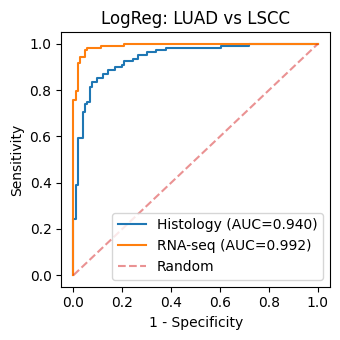

In [9]:
# evaluate models
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

hist_fpr, hist_tpr, _ = roc_curve(y_true=y_test, y_score=y_hist_prob[:, 1])
hist_auc = roc_auc_score(y_true=y_test, y_score=y_hist_prob[:, 1])

expr_fpr, expr_tpr, _ = roc_curve(y_true=y_test, y_score=y_expr_prob[:, 1])
expr_auc = roc_auc_score(y_true=y_test, y_score=y_expr_prob[:, 1])

fig, ax = plt.subplots(figsize=(3.5, 3.5))
ax.plot(hist_fpr, hist_tpr, label=f"Histology (AUC={hist_auc:0.3f})")
ax.plot(expr_fpr, expr_tpr, label=f"RNA-seq (AUC={expr_auc:0.3f})")
ax.plot([0, 1], [0, 1], label="Random", linestyle="--", color="tab:red", alpha=0.5)
ax.legend()
ax.set(xlabel="1 - Specificity", ylabel="Sensitivity", title="LogReg: LUAD vs LSCC")
fig.tight_layout()

## k-Nearest Neighbors (kNN)

Instead of bulk retrieving embeddings, we can also leverage the Gen3 Embedding Service's vector similarity search functionality to do neighborhood-based classification. That is, the `TCGA-LUAD/LUSC` will be the "training" neighborhood data for a k-nearest neighbor classifier.

The potential benefit of this approach is that we can make predictions in a _**privacy preserving**_ manner: the embeddings which define the latent-space neighborhood never has to leave the commons and only non-sensitive metadata is returned (in this case, the NSCLC type).

In [10]:
# setup the similarity search using the gen3 embedding service
import requests
from gen3.auth import Gen3Auth

EMBEDDING_API = "https://genomicaicommons.org/ai/vectorstore/collections"
auth = Gen3Auth()

def similarity_search(query_vector: np.ndarray, *, collection: str, k: int) -> np.ndarray:
    data = requests.post(
        f"{EMBEDDING_API}/{collection}/search", auth=auth,
        json={
            "input": query_vector.tolist(), "top_k": k, "distance_metric": "cosine_similarity",
            "filters": {"primary_site": "bronchus and lung"}, # only search over TCGA-LUAD/LUSC
        },
    ).json()
    # display(data)
    labels = [
        # 0 = adenocarcinoma, 1 = squamous cell carcinoma
        int(x["embedding"]["info"]["metadata"]["project_id"] == "TCGA-LUSC")
        for x in data["embeddings"]
    ]
    return np.asarray(labels)

#### Computing NSCLC-type probability

With the similarity search method in hand, we can compute the predicted probability of the NSCLC type using the prevalence of each type in the neighborhood of a query input. For example, consider CPTAC case `C3L-00081` which we know is a case of squamous cell carcinoma.

The tumor slide for this case looks like this:

<img src="nsclc-eval-data/C3L-00081-thumb.png" alt="C3L-00081 WSI" width="200"/>

We can compute it's predicted NSCLC-type as follows:

In [11]:
# example case ID
case_id = "C3L-00081" # we know this is squam

# get the case's WSI embedding
idx = hist_test_squam_cases.index(case_id)
query_vec = X_hist_test_squam[idx]

# get the labels of the TCGA-NSCLC neighborhood with k=10
k = 10
labels = similarity_search(query_vec, collection="hist", k=k)

# compute probability of squam - keep in mind, we've encoded 0 = adeno and 1 = squam
prob = labels.mean()

print(f"{case_id} is predicted to be squam with {int(prob*100)}% probability using a TCGA-NSCLC neighborhood size of k={k}")

C3L-00081 is predicted to be squam with 90% probability using a TCGA-NSCLC neighborhood size of k=10


#### Evaluating effect of neighborhood size on predictive performance

The key hyperparameter to tune for a kNN is the neighborhood size (k). Here, we sweep varying k's using the embedding service to assess NSCLC classification performance.

In [12]:
# run the neighborhood size sweep and compute AUROC
import numpy as np
from sklearn.metrics import roc_auc_score
from tqdm.contrib.concurrent import thread_map

ks = [1, 2, 3, 5, 10, 25]
hist_aucs = []
expr_aucs = []
for collection, X_test, y_test, aucs in [
    ["hist", X_hist_test, y_test, hist_aucs],
    ["expr", X_expr_test, y_test, expr_aucs],
]:
    for k in ks:
        _fn = lambda x: similarity_search(x, collection=collection, k=k)
        labels = thread_map(_fn, X_test, max_workers=8, desc=f"{collection}, k={k}")
        y_probs = np.asarray(labels).mean(axis=1) # predicted prob for squam
        auc = roc_auc_score(y_true=y_test, y_score=y_probs)
        aucs.append(auc)

hist, k=1:   0%|          | 0/214 [00:00<?, ?it/s]

hist, k=2:   0%|          | 0/214 [00:00<?, ?it/s]

hist, k=3:   0%|          | 0/214 [00:00<?, ?it/s]

hist, k=5:   0%|          | 0/214 [00:00<?, ?it/s]

hist, k=10:   0%|          | 0/214 [00:00<?, ?it/s]

...

expr, k=2:   0%|          | 0/214 [00:00<?, ?it/s]

expr, k=3:   0%|          | 0/214 [00:00<?, ?it/s]

expr, k=5:   0%|          | 0/214 [00:00<?, ?it/s]

expr, k=10:   0%|          | 0/214 [00:00<?, ?it/s]

expr, k=25:   0%|          | 0/214 [00:00<?, ?it/s]

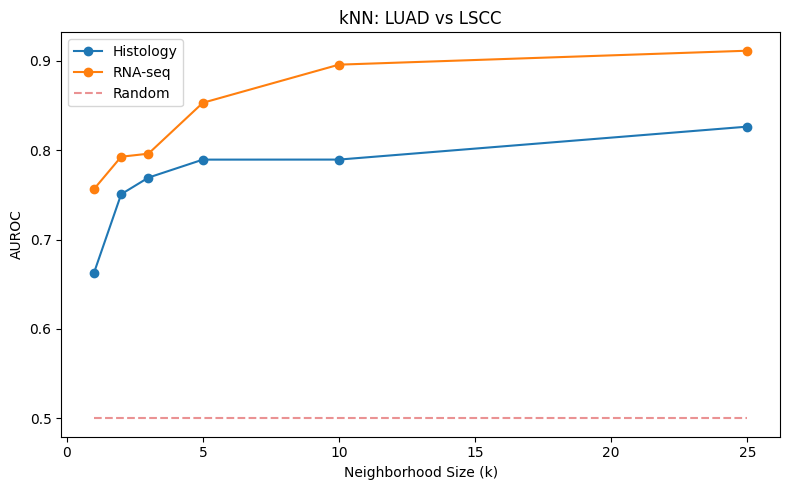

In [13]:
# plot kNN results
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(ks, hist_aucs, label=f"Histology", marker="o")
ax.plot(ks, expr_aucs, label=f"RNA-seq", marker="o")
ax.plot(ks, [0.5] * len(ks), label=f"Random", color="tab:red", alpha=0.5, linestyle="--")
ax.legend()
ax.set(xlabel="Neighborhood Size (k)", ylabel="AUROC", title="kNN: LUAD vs LSCC")
fig.tight_layout()